In [1]:
# ============================================================================
# Environment
#   Python >= 3.10. Install dependencies with:
#       pip install -r requirements.txt
#   Run this notebook from the directory that contains it -- the one holding
#   survey_data/ -- so the relative ./survey_data/ paths below resolve.
# ============================================================================

import sys, os
print("Python:", sys.version.split()[0])
print("Working directory:", os.getcwd())
assert os.path.isdir("./survey_data"), (
    "./survey_data not found. Start Jupyter from the directory that contains "
    "this notebook and survey_data/, then re-run this cell."
)


# Generated figures are written here, not to the notebook's directory.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

import pandas as pd
df = pd.read_excel("./survey_data/survey_results/survey_results.xlsx")
df["j"] = df["j"].fillna("NA").astype(str)
df["j_2"] = df["j_2"].fillna("NA").astype(str)
# Compute change variables at participant level
df["judgment_changed"] = (df["j"] != df["j_2"]).astype(int)
df["confidence_changed"] = (df["c"] != df["c_2"]).astype(int)
df["any_change"] = ((df["j"] != df["j_2"]) | (df["c"] != df["c_2"])).astype(int)

# Capture direction of confidence change
df["confidence_increased"] = (df["c_2"] > df["c"]).astype(int)
df["confidence_decreased"] = (df["c_2"] < df["c"]).astype(int)
df["confidence_no_change"] = (df["c_2"] == df["c"]).astype(int)


Python: 3.10.13
Working directory: /Users/ziyuchen/AITA_data_profiling/controversy_certainty


# change rate

## quandrants

### weakening


STATISTICAL TEST RESULTS (within-treatment, BH-adjusted within family)

CONTROL: single bar, 5.3% (n=1070), no comparison

CONTROVERSY:
------------------------------------------------------------------------------------------------------------------------
  Majority 7.9% vs Minority 27.3%
    -> p=8.682380066972984e-18, adj_p=8.682380066972984e-18 ***

CERTAINTY:
------------------------------------------------------------------------------------------------------------------------
  Ingroup>=Outgroup 5.3% vs Ingroup<Outgroup 18.5%
    -> p=3.7012779358157235e-12, adj_p=3.7012779358157235e-12 ***

CONTROVERSY CERTAINTY:
------------------------------------------------------------------------------------------------------------------------
  Ingroup>=Outgroup: Majority 4.0% vs Minority 18.1%
    -> p=1.758517788857718e-09, adj_p=7.034071155430872e-09 ***
  Ingroup<Outgroup: Majority 11.7% vs Minority 20.3%
    -> p=0.01615755233018317, adj_p=0.021543403106910892 *
  Majority: Ingroup>

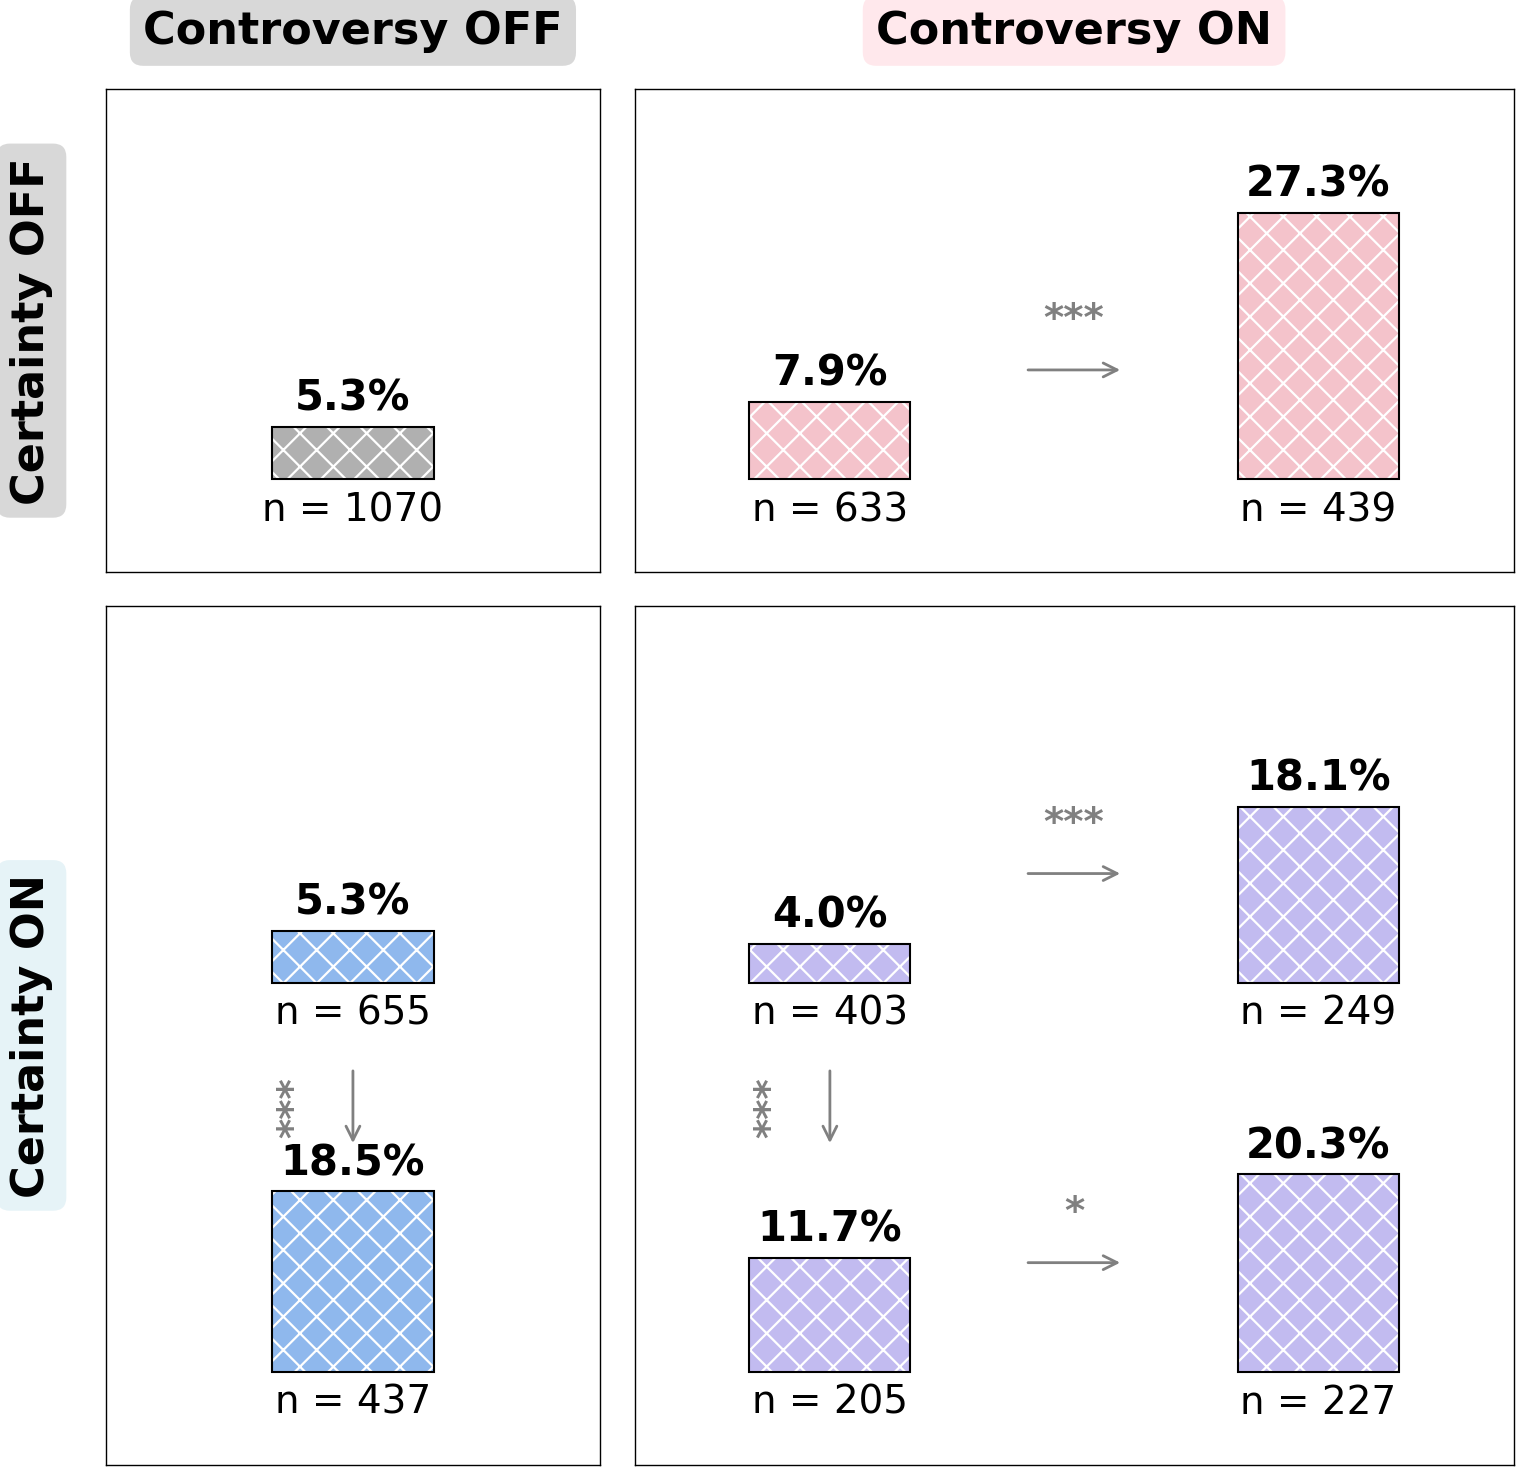

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import barnard_exact
from matplotlib.patches import FancyArrowPatch
from scipy.stats import false_discovery_control
from matplotlib.gridspec import GridSpec

# White hatching styling (set globally so 'hatch' arg uses these)
mpl.rcParams['hatch.color'] = 'white'
mpl.rcParams['hatch.linewidth'] = 1.6

# =============================================================
# Global Configuration Variables
# =============================================================
PERCENTAGE_FONT_SIZE = 30
SAMPLE_SIZE_FONT_SIZE = 28
AXIS_LABEL_FONT_SIZE = 20
SIGNIFICANCE_FONT_SIZE = 28
CORNER_LABEL_FONT_SIZE = 32
CROSS_SIG_FONT_SIZE = 26  # cross-treatment annotations

XLIM_RANGE = 0.4
YLIM_RANGE = 0.42

BAR_HATCH = 'x'

COL_NARROW = 0.45
COL_WIDE = 0.8
ROW_SHORT = 0.45
ROW_TALL = 0.8

X_SHRINK = COL_NARROW / COL_WIDE
Y_SHRINK = ROW_SHORT / ROW_TALL

# =============================================================
# Helpers
# =============================================================

def barnard_two_sided_test(successes1, total1, successes2, total2, alternative='two-sided'):
    failures1 = total1 - successes1
    failures2 = total2 - successes2
    table = [[successes1, successes2], [failures1, failures2]]
    return barnard_exact(table, alternative=alternative).pvalue

def benjamini_hochberg(p_values, alpha=0.05):
    p_values = np.array(p_values)
    adjusted_p = false_discovery_control(p_values, method='bh')
    return adjusted_p, adjusted_p <= alpha

def sig_symbol_from_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


def run_treatment_specific_comparisons(grouped_df, grouped_controversy, grouped_certainty):
    all_results = []

    cont_data = grouped_controversy[grouped_controversy['treatment'] == 'controversy']
    cont_dict = {row['disagreement_level']: {
        'movements': int(row['movements']),
        'total': int(row['total']),
        'frequency': float(row['frequency'])
    } for _, row in cont_data.iterrows()}

    if 'Low' in cont_dict and 'High' in cont_dict:
        maj = cont_dict['Low']
        minr = cont_dict['High']
        p_val = barnard_two_sided_test(maj['movements'], maj['total'],
                                       minr['movements'], minr['total'], 'two-sided')
        adj_p, reject = benjamini_hochberg([p_val], alpha=0.05)
        all_results.append({
            'treatment': 'controversy',
            'comparison_type': 'majority_vs_minority',
            'comparison_desc': f"Majority {maj['frequency']:.1f}% vs Minority {minr['frequency']:.1f}%",
            'cell1': 'Low', 'cell2': 'High',
            'rate1': maj['frequency'], 'rate2': minr['frequency'],
            'p_value': p_val, 'adj_p_value': adj_p[0],
            'significant': reject[0],
            'sig_symbol': sig_symbol_from_p(adj_p[0]),
            'direction': 'horizontal'
        })

    cert_data = grouped_certainty[grouped_certainty['treatment'] == 'certainty']
    cert_dict = {row['certainty_diff_level']: {
        'movements': int(row['movements']),
        'total': int(row['total']),
        'frequency': float(row['frequency'])
    } for _, row in cert_data.iterrows()}

    if 'High' in cert_dict and 'Low' in cert_dict:
        ing = cert_dict['High']
        out = cert_dict['Low']
        p_val = barnard_two_sided_test(ing['movements'], ing['total'],
                                       out['movements'], out['total'], 'two-sided')
        adj_p, reject = benjamini_hochberg([p_val], alpha=0.05)
        all_results.append({
            'treatment': 'certainty',
            'comparison_type': 'ingroup_vs_outgroup_certainty',
            'comparison_desc': f"Ingroup>=Outgroup {ing['frequency']:.1f}% vs Ingroup<Outgroup {out['frequency']:.1f}%",
            'cell1': 'High', 'cell2': 'Low',
            'rate1': ing['frequency'], 'rate2': out['frequency'],
            'p_value': p_val, 'adj_p_value': adj_p[0],
            'significant': reject[0],
            'sig_symbol': sig_symbol_from_p(adj_p[0]),
            'direction': 'vertical'
        })

    treatment = 'controversy_certainty'
    treatment_data = grouped_df[grouped_df['treatment'] == treatment].copy()
    data_dict = {}
    for _, row in treatment_data.iterrows():
        key = (row['disagreement_level'], row['certainty_diff_level'])
        data_dict[key] = {
            'movements': int(row['movements']),
            'total': int(row['total']),
            'frequency': float(row['frequency'])
        }

    comparisons = []

    if ('Low', 'High') in data_dict and ('High', 'High') in data_dict:
        maj = data_dict[('Low', 'High')]; minr = data_dict[('High', 'High')]
        p_val = barnard_two_sided_test(maj['movements'], maj['total'],
                                       minr['movements'], minr['total'], 'two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'row_high',
            'comparison_desc': f"Ingroup>=Outgroup: Majority {maj['frequency']:.1f}% vs Minority {minr['frequency']:.1f}%",
            'cell1': ('Low', 'High'), 'cell2': ('High', 'High'),
            'rate1': maj['frequency'], 'rate2': minr['frequency'],
            'p_value': p_val, 'direction': 'horizontal'
        })

    if ('Low', 'Low') in data_dict and ('High', 'Low') in data_dict:
        maj = data_dict[('Low', 'Low')]; minr = data_dict[('High', 'Low')]
        p_val = barnard_two_sided_test(maj['movements'], maj['total'],
                                       minr['movements'], minr['total'], 'two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'row_low',
            'comparison_desc': f"Ingroup<Outgroup: Majority {maj['frequency']:.1f}% vs Minority {minr['frequency']:.1f}%",
            'cell1': ('Low', 'Low'), 'cell2': ('High', 'Low'),
            'rate1': maj['frequency'], 'rate2': minr['frequency'],
            'p_value': p_val, 'direction': 'horizontal'
        })

    if ('Low', 'Low') in data_dict and ('Low', 'High') in data_dict:
        out = data_dict[('Low', 'Low')]; ing = data_dict[('Low', 'High')]
        p_val = barnard_two_sided_test(ing['movements'], ing['total'],
                                       out['movements'], out['total'], 'two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'col_low',
            'comparison_desc': f"Majority: Ingroup>=Outgroup {ing['frequency']:.1f}% vs Ingroup<Outgroup {out['frequency']:.1f}%",
            'cell1': ('Low', 'High'), 'cell2': ('Low', 'Low'),
            'rate1': ing['frequency'], 'rate2': out['frequency'],
            'p_value': p_val, 'direction': 'vertical'
        })

    if ('High', 'Low') in data_dict and ('High', 'High') in data_dict:
        out = data_dict[('High', 'Low')]; ing = data_dict[('High', 'High')]
        p_val = barnard_two_sided_test(ing['movements'], ing['total'],
                                       out['movements'], out['total'], 'two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'col_high',
            'comparison_desc': f"Minority: Ingroup>=Outgroup {ing['frequency']:.1f}% vs Ingroup<Outgroup {out['frequency']:.1f}%",
            'cell1': ('High', 'High'), 'cell2': ('High', 'Low'),
            'rate1': ing['frequency'], 'rate2': out['frequency'],
            'p_value': p_val, 'direction': 'vertical'
        })

    if comparisons:
        p_values = [c['p_value'] for c in comparisons]
        adj_p_values, rejections = benjamini_hochberg(p_values, alpha=0.05)
        for i, comp in enumerate(comparisons):
            comp['adj_p_value'] = adj_p_values[i]
            comp['significant'] = rejections[i]
            comp['sig_symbol'] = sig_symbol_from_p(adj_p_values[i])
            all_results.append(comp)

    return pd.DataFrame(all_results)


# =============================================================
# Cross-treatment comparisons (no C+C collapsing)
# 8 tests total, BH-corrected as one family:
#   Controversy(Maj)        vs C+C(Maj, Ing>=Out)
#   Controversy(Maj)        vs C+C(Maj, Ing<Out)
#   Controversy(Min)        vs C+C(Min, Ing>=Out)
#   Controversy(Min)        vs C+C(Min, Ing<Out)
#   Certainty(Ing>=Out)      vs C+C(Maj, Ing>=Out)
#   Certainty(Ing>=Out)      vs C+C(Min, Ing>=Out)
#   Certainty(Ing<Out)     vs C+C(Maj, Ing<Out)
#   Certainty(Ing<Out)     vs C+C(Min, Ing<Out)
# Each test compares the additive treatment cell against the
# matching C+C subcell (matched on the dimension the additive
# treatment shows). Two-sided: the direction is not chosen from the data.
# =============================================================

def run_cross_treatment_comparisons(df_in):

    def collect_cell(df_sub):
        n = int(df_sub.shape[0])
        k = int(df_sub['movement_away_original'].sum()) if n > 0 else 0
        rate = (k / n * 100) if n > 0 else float('nan')
        return n, k, rate

    # --- Family 1: Controversy vs C+C (4 tests) ---
    family_controversy = []
    for dis_level, dis_label in [('Low', 'Majority'), ('High', 'Minority')]:
        cont = df_in[(df_in['treatment'] == 'controversy') &
                     (df_in['disagreement_level'] == dis_level)]
        n_a, k_a, r_a = collect_cell(cont)

        for cert_level, cert_label in [('High', 'Ing>=Out'), ('Low', 'Ing<Out')]:
            cc = df_in[(df_in['treatment'] == 'controversy_certainty') &
                       (df_in['disagreement_level'] == dis_level) &
                       (df_in['certainty_diff_level'] == cert_level)]
            n_b, k_b, r_b = collect_cell(cc)

            higher = None; p_val = float('nan')
            if n_a > 0 and n_b > 0:
                if r_a >= r_b:
                    higher = 'controversy'
                    table = [[k_a, k_b], [n_a - k_a, n_b - k_b]]
                else:
                    higher = 'controversy_certainty'
                    table = [[k_b, k_a], [n_b - k_b, n_a - k_a]]
                try:
                    p_val = barnard_exact(table, alternative='two-sided').pvalue
                except Exception:
                    p_val = float('nan')

            family_controversy.append({
                'comparison': 'controversy_vs_cc',
                'family': 'controversy_vs_cc',
                'subgroup_label': f'{dis_label}, {cert_label}',
                'treatment_a': 'controversy',
                'treatment_b': f'C+C ({dis_label}, {cert_label})',
                'rate_a': r_a, 'rate_b': r_b,
                'n_a': n_a, 'n_b': n_b,
                'higher': higher, 'p_value': p_val,
            })

    # --- Family 2: Certainty vs C+C (4 tests) ---
    family_certainty = []
    for cert_level, cert_label in [('High', 'Ing>=Out'), ('Low', 'Ing<Out')]:
        cert = df_in[(df_in['treatment'] == 'certainty') &
                     (df_in['certainty_diff_level'] == cert_level)]
        n_a, k_a, r_a = collect_cell(cert)

        for dis_level, dis_label in [('Low', 'Majority'), ('High', 'Minority')]:
            cc = df_in[(df_in['treatment'] == 'controversy_certainty') &
                       (df_in['disagreement_level'] == dis_level) &
                       (df_in['certainty_diff_level'] == cert_level)]
            n_b, k_b, r_b = collect_cell(cc)

            higher = None; p_val = float('nan')
            if n_a > 0 and n_b > 0:
                if r_a >= r_b:
                    higher = 'certainty'
                    table = [[k_a, k_b], [n_a - k_a, n_b - k_b]]
                else:
                    higher = 'controversy_certainty'
                    table = [[k_b, k_a], [n_b - k_b, n_a - k_a]]
                try:
                    p_val = barnard_exact(table, alternative='two-sided').pvalue
                except Exception:
                    p_val = float('nan')

            family_certainty.append({
                'comparison': 'certainty_vs_cc',
                'family': 'certainty_vs_cc',
                'subgroup_label': f'{cert_label}, {dis_label}',
                'treatment_a': 'certainty',
                'treatment_b': f'C+C ({dis_label}, {cert_label})',
                'rate_a': r_a, 'rate_b': r_b,
                'n_a': n_a, 'n_b': n_b,
                'higher': higher, 'p_value': p_val,
            })

    # Apply BH correction within each family separately
    def apply_bh_within_family(family):
        pvals = np.array([p['p_value'] for p in family], dtype=float)
        valid = ~np.isnan(pvals)
        adj = np.full_like(pvals, np.nan, dtype=float)
        if valid.any():
            adj[valid] = false_discovery_control(pvals[valid], method='bh')
        for i, p in enumerate(family):
            p['adj_p_value'] = adj[i]
            p['sig_symbol'] = sig_symbol_from_p(adj[i])
        return family

    family_controversy = apply_bh_within_family(family_controversy)
    family_certainty = apply_bh_within_family(family_certainty)

    return pd.DataFrame(family_controversy + family_certainty)

# =============================================================
# Data Preparation (unchanged from previous)
# =============================================================

df['disagreement_rate'] = df.apply(
    lambda row: row['post_YA_Percentage'] if row['j'] == 'NA' else row['post_NA_Percentage'],
    axis=1
)
df['ingroup_certainty'] = df.apply(
    lambda row: row['post_certain_YA'] if row['j'] == 'YA' else row['post_certain_NA'],
    axis=1
)
df['outgroup_certainty'] = df.apply(
    lambda row: row['post_certain_NA'] if row['j'] == 'YA' else row['post_certain_YA'],
    axis=1
)
df['certainty_diff'] = df['ingroup_certainty'] - df['outgroup_certainty']

disagree_median = 50
certainty_median = 0
df['disagreement_level'] = df['disagreement_rate'].apply(lambda x: 'Low' if x < disagree_median else 'High')
df['certainty_diff_level'] = df['certainty_diff'].apply(lambda x: 'Low' if x < certainty_median else 'High')
df['movement_away_original'] = (
    (df['j'] != df['j_2']) | ((df['j'] == df['j_2']) & (df['c_2'] < df['c']))
).astype(int)

grouped = df.groupby(['disagreement_level', 'certainty_diff_level', 'treatment']).agg(
    movements=('movement_away_original', 'sum'),
    total=('movement_away_original', 'count')
).reset_index()
grouped['frequency'] = (grouped['movements'] / grouped['total'] * 100)
grouped = grouped[grouped['total'] > 0]

grouped_controversy = df.groupby(['disagreement_level', 'treatment']).agg(
    movements=('movement_away_original', 'sum'),
    total=('movement_away_original', 'count')
).reset_index()
grouped_controversy['frequency'] = (grouped_controversy['movements'] / grouped_controversy['total'] * 100)
grouped_controversy = grouped_controversy[grouped_controversy['total'] > 0]

grouped_certainty = df.groupby(['certainty_diff_level', 'treatment']).agg(
    movements=('movement_away_original', 'sum'),
    total=('movement_away_original', 'count')
).reset_index()
grouped_certainty['frequency'] = (grouped_certainty['movements'] / grouped_certainty['total'] * 100)
grouped_certainty = grouped_certainty[grouped_certainty['total'] > 0]

control_movements = int(df[df['treatment'] == 'control']['movement_away_original'].sum())
control_total = int(df[df['treatment'] == 'control']['movement_away_original'].count())
control_freq = control_movements / control_total * 100 if control_total > 0 else 0

sig_results = run_treatment_specific_comparisons(grouped, grouped_controversy, grouped_certainty)
cross_results = run_cross_treatment_comparisons(df)

# Print everything
print("\n" + "=" * 120)
print("STATISTICAL TEST RESULTS (within-treatment, BH-adjusted within family)")
print("=" * 120)
print(f"\nCONTROL: single bar, {control_freq:.1f}% (n={control_total}), no comparison")
for treatment in ['controversy', 'certainty', 'controversy_certainty']:
    treatment_results = sig_results[sig_results['treatment'] == treatment]
    if not treatment_results.empty:
        print(f"\n{treatment.upper().replace('_', ' ')}:")
        print("-" * 120)
        for _, row in treatment_results.iterrows():
            sig_marker = f" {row['sig_symbol']}" if row['sig_symbol'] else ""
            print(f"  {row['comparison_desc']}")
            print(f"    -> p={row['p_value']}, adj_p={row['adj_p_value']}{sig_marker}")

print("\n" + "=" * 120)
print("CROSS-TREATMENT COMPARISONS (BH-adjusted within each treatment pair, family size = 4)")
print("=" * 120)
for family_name in ['controversy_vs_cc', 'certainty_vs_cc']:
    family_rows = cross_results[cross_results['family'] == family_name]
    if family_rows.empty:
        continue
    print(f"\nFamily: {family_name.replace('_', ' ').upper()}")
    print("-" * 120)
    for _, row in family_rows.iterrows():
        sig_marker = f" {row['sig_symbol']}" if row['sig_symbol'] else ""
        a = row['treatment_a']; b = row['treatment_b']
        print(f"  [{row['subgroup_label']}] {a} {row['rate_a']:.1f}% (n={row['n_a']})  vs  "
              f"{b} {row['rate_b']:.1f}% (n={row['n_b']})  -- higher: {row['higher']}")
        print(f"    -> p={row['p_value']}, adj_p={row['adj_p_value']}{sig_marker}")
print("=" * 120 + "\n")

# =============================================================
# Visualization
# =============================================================

treatment_colors = {
    'control': '#B0B0B0',
    'controversy': '#F4C3CB',
    'certainty': '#8FB8ED',
    'controversy_certainty': '#C2BBF0'
}

bar_width = 0.33
height_scale = 0.025

fig = plt.figure(figsize=(16, 16))
gs = GridSpec(2, 2,
              width_ratios=[COL_NARROW, COL_WIDE],
              height_ratios=[ROW_SHORT, ROW_TALL],
              wspace=0.05, hspace=0.05,
              left=0.08, right=0.96, top=0.92, bottom=0.06)

ax_control = fig.add_subplot(gs[0, 0])
ax_controversy = fig.add_subplot(gs[0, 1])
ax_certainty = fig.add_subplot(gs[1, 0])
ax_cc = fig.add_subplot(gs[1, 1])

disagreement_map = {'Low': 0, 'High': 1}
certainty_map = {'Low': 0, 'High': 1}

xlim_wide = (0 - XLIM_RANGE, 1 + XLIM_RANGE)
xspan_wide = xlim_wide[1] - xlim_wide[0]
xspan_narrow = xspan_wide * X_SHRINK
xlim_narrow = (0.5 - xspan_narrow / 2, 0.5 + xspan_narrow / 2)

ylim_tall = (-0.1 - YLIM_RANGE, 1.1 + YLIM_RANGE * 1.4)
yspan_tall = ylim_tall[1] - ylim_tall[0]
yspan_short = yspan_tall * Y_SHRINK
ylim_short = (ylim_tall[0], ylim_tall[0] + yspan_short)


def draw_bar(ax, x_center, base_y, bar_height, color, freq, n):
    bars = ax.bar(x_center, bar_height, width=bar_width, bottom=base_y,
                  color=color, edgecolor='black', linewidth=1.5,
                  hatch=BAR_HATCH, zorder=3)
    # Force hatch color to white on each patch (rcParam alone is unreliable
    # when edgecolor is set on the bar).
    for patch in bars:
        patch.set_hatch(BAR_HATCH)
        patch._hatch_color = (1.0, 1.0, 1.0, 1.0)  # white in RGBA
    ax.text(x_center, base_y + bar_height + 0.02, f'{freq:.1f}%',
            fontsize=PERCENTAGE_FONT_SIZE, ha='center', va='bottom',
            fontweight='bold', zorder=4)
    ax.text(x_center, base_y - 0.03, f'n = {n}',
            fontsize=SAMPLE_SIZE_FONT_SIZE, ha='center', va='top',
            fontweight='normal', color='black', zorder=4)


def style_axes(ax, xlim, ylim, xticks=None, yticks=None,
               xticklabels=None, yticklabels=None,
               x_minor=None, y_minor=None):
    if xticks is not None:
        ax.set_xticks(xticks)
        if xticklabels is not None:
            ax.set_xticklabels(xticklabels, fontsize=AXIS_LABEL_FONT_SIZE,
                               fontweight='bold', ha='center')
    if yticks is not None:
        ax.set_yticks(yticks)
        if yticklabels is not None:
            ax.set_yticklabels(yticklabels, fontsize=AXIS_LABEL_FONT_SIZE,
                               fontweight='bold', rotation=90, va='center')
    if x_minor is not None:
        ax.set_xticks(x_minor, minor=True)
    if y_minor is not None:
        ax.set_yticks(y_minor, minor=True)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')  # light gray
    ax.tick_params(axis='both', which='both', length=0)

# ---- CONTROL ----
x_center = 0.5
base_y = 0 - 0.28
bar_height_ctrl = control_freq * height_scale
draw_bar(ax_control, x_center, base_y, bar_height_ctrl,
         treatment_colors['control'], control_freq, control_total)
style_axes(ax_control, xlim=xlim_narrow, ylim=ylim_short,
           xticks=[0.5], xticklabels=[''])
ax_control.set_yticks([])

# ---- CONTROVERSY ----
cont_data = grouped_controversy[grouped_controversy['treatment'] == 'controversy']
for dis_level in ['Low', 'High']:
    subset = cont_data[cont_data['disagreement_level'] == dis_level]
    if not subset.empty:
        freq = subset['frequency'].values[0]
        n = subset['total'].values[0]
        bh = freq * height_scale
        x_c = disagreement_map[dis_level]
        b_y = 0 - 0.28
        draw_bar(ax_controversy, x_c, b_y, bh,
                 treatment_colors['controversy'], freq, n)

cont_sigs = sig_results[sig_results['treatment'] == 'controversy']
for _, sig_row in cont_sigs.iterrows():
    if sig_row['sig_symbol']:
        x1 = disagreement_map[sig_row['cell1']]
        x2 = disagreement_map[sig_row['cell2']]
        y_pos = 0
        arrow = FancyArrowPatch((x1 + 0.4, y_pos), (x2 - 0.4, y_pos),
                                arrowstyle='->', mutation_scale=25, linewidth=2,
                                color='gray', zorder=6)
        ax_controversy.add_patch(arrow)
        ax_controversy.text((x1 + x2) / 2, y_pos + 0.08, sig_row['sig_symbol'],
                            fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                            ha='center', va='bottom', fontweight='bold', zorder=6)

style_axes(ax_controversy, xlim=xlim_wide, ylim=ylim_short,
           xticks=[0, 1], xticklabels=['', ''], x_minor=[0.5])
ax_controversy.set_yticks([])

# ---- CERTAINTY ----
cert_data = grouped_certainty[grouped_certainty['treatment'] == 'certainty']
for cert_level in ['Low', 'High']:
    subset = cert_data[cert_data['certainty_diff_level'] == cert_level]
    if not subset.empty:
        freq = subset['frequency'].values[0]
        n = subset['total'].values[0]
        bh = freq * height_scale
        x_c = 0.5
        y_c = certainty_map[cert_level]
        b_y = y_c - 0.28
        draw_bar(ax_certainty, x_c, b_y, bh,
                 treatment_colors['certainty'], freq, n)

cert_sigs = sig_results[sig_results['treatment'] == 'certainty']
for _, sig_row in cert_sigs.iterrows():
    if sig_row['sig_symbol']:
        y1 = certainty_map[sig_row['cell1']]
        y2 = certainty_map[sig_row['cell2']]
        x_pos = 0.5
        arrow = FancyArrowPatch((x_pos, y1 - 0.5), (x_pos, y2 + 0.3),
                                arrowstyle='->', mutation_scale=25, linewidth=2,
                                color='gray', zorder=6)
        ax_certainty.add_patch(arrow)
        ax_certainty.text(x_pos - 0.12, (y1 + y2 - 0.2) / 2, sig_row['sig_symbol'],
                          fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                          ha='center', va='center', fontweight='bold',
                          rotation=90, zorder=6)

style_axes(ax_certainty, xlim=xlim_narrow, ylim=ylim_tall,
           xticks=[0.5], xticklabels=[''],
           yticks=[0, 1], yticklabels=['', ''], y_minor=[0.5])

# ---- C+C ----
cc_data = grouped[grouped['treatment'] == 'controversy_certainty']
for dis_level in ['Low', 'High']:
    for cert_level in ['Low', 'High']:
        subset = cc_data[
            (cc_data['disagreement_level'] == dis_level) &
            (cc_data['certainty_diff_level'] == cert_level)
        ]
        if not subset.empty:
            freq = subset['frequency'].values[0]
            n = subset['total'].values[0]
            bh = freq * height_scale
            x_c = disagreement_map[dis_level]
            y_c = certainty_map[cert_level]
            b_y = y_c - 0.28
            draw_bar(ax_cc, x_c, b_y, bh,
                     treatment_colors['controversy_certainty'], freq, n)

cc_sigs = sig_results[sig_results['treatment'] == 'controversy_certainty']
for _, sig_row in cc_sigs.iterrows():
    if sig_row['sig_symbol']:
        cell1 = sig_row['cell1']; cell2 = sig_row['cell2']
        x1 = disagreement_map[cell1[0]]; y1 = certainty_map[cell1[1]]
        x2 = disagreement_map[cell2[0]]; y2 = certainty_map[cell2[1]]
        if sig_row['direction'] == 'horizontal':
            y_pos = y1
            arrow = FancyArrowPatch((x1 + 0.4, y_pos), (x2 - 0.4, y_pos),
                                    arrowstyle='->', mutation_scale=25, linewidth=2,
                                    color='gray', zorder=6)
            ax_cc.add_patch(arrow)
            ax_cc.text((x1 + x2) / 2, y_pos + 0.08, sig_row['sig_symbol'],
                       fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                       ha='center', va='bottom', fontweight='bold', zorder=6)
        else:
            x_pos = x1
            arrow = FancyArrowPatch((x_pos, y1 - 0.5), (x_pos, y2 + 0.3),
                                    arrowstyle='->', mutation_scale=25, linewidth=2,
                                    color='gray', zorder=6)
            ax_cc.add_patch(arrow)
            ax_cc.text(x_pos - 0.12, (y1 + y2 - 0.2) / 2, sig_row['sig_symbol'],
                       fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                       ha='center', va='center', fontweight='bold',
                       rotation=90, zorder=6)

style_axes(ax_cc, xlim=xlim_wide, ylim=ylim_tall,
           xticks=[0, 1], xticklabels=['', ''],
           yticks=[0, 1], yticklabels=['', ''],
           x_minor=[0.5], y_minor=[0.5])

# ---- Corner labels ----
ax_control.text(0.5, 1.12, 'Controversy OFF',
                transform=ax_control.transAxes,
                ha='center', va='center',
                fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='gray', edgecolor='none', alpha=0.3))

ax_controversy.text(0.5, 1.12, 'Controversy ON',
                    transform=ax_controversy.transAxes,
                    ha='center', va='center',
                    fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightpink', edgecolor='none', alpha=0.3))

ax_control.text(-0.15, 0.5, 'Certainty OFF',
                transform=ax_control.transAxes,
                ha='center', va='center',
                fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold', rotation=90,
                bbox=dict(boxstyle='round', facecolor='gray', edgecolor='none', alpha=0.3))

ax_certainty.text(-0.15, 0.5, 'Certainty ON',
                  transform=ax_certainty.transAxes,
                  ha='center', va='center',
                  fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold', rotation=90,
                  bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='none', alpha=0.3))


# =============================================================
# Cross-treatment statistical results are printed to the console
# above (see `cross_results`). No cross-treatment annotations are
# drawn on the figure.
# =============================================================

plt.savefig(os.path.join(FIG_DIR, "fig3b_weakening_quadrant.png"), dpi=1000, bbox_inches='tight')
plt.show()

### strengthening

Reinforcement sample size: 1924 (20.3% reinforced)

REINFORCEMENT ANALYSIS - Within-treatment Statistical Test Results

CONTROL: single bar, 8.6% (n=463), no comparison

CONTROVERSY:
------------------------------------------------------------------------------------------------------------------------
  Majority 35.1% vs Minority 14.4%
    -> p=2.0207331050821858e-07, adj_p=2.0207331050821858e-07 ***

CERTAINTY:
------------------------------------------------------------------------------------------------------------------------
  Ingroup>=Outgroup 32.4% vs Ingroup<Outgroup 16.6%
    -> p=0.00011233294314948705, adj_p=0.00011233294314948705 ***

CONTROVERSY CERTAINTY:
------------------------------------------------------------------------------------------------------------------------
  Ingroup>=Outgroup: Majority 34.9% vs Minority 10.9%
    -> p=1.556729207261693e-06, adj_p=6.226916829046772e-06 ***
  Ingroup<Outgroup: Majority 22.5% vs Minority 9.7%
    -> p=0.010541595261575911

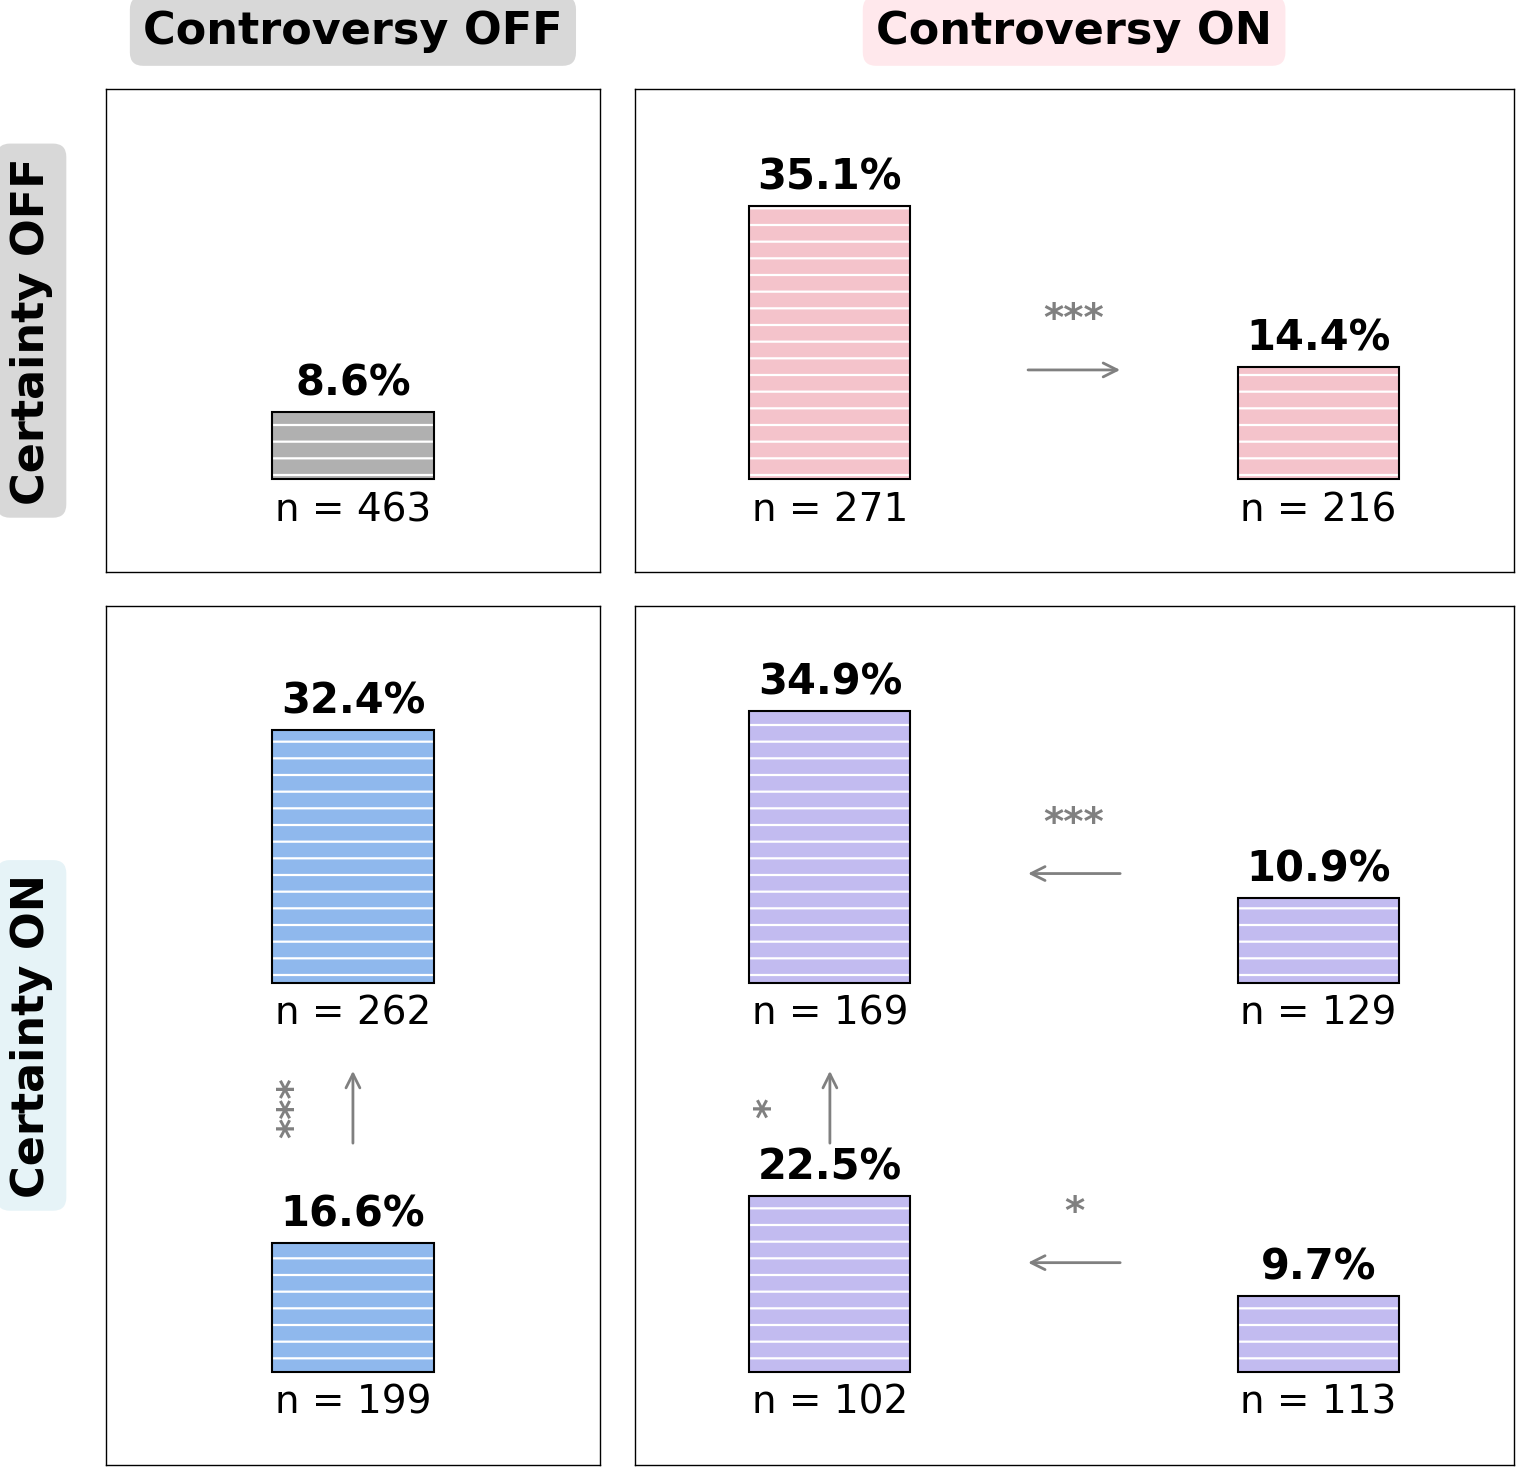

In [3]:
"""
Reinforced (Strengthened) Analysis - Asymmetric Layout
=======================================================
Mirrors the weakening visualization but targets the reinforcement
sample:
  - Initial confidence c < 4  (room to increase)
  - Judgment did not change: j == j_2
  - reinforced = 1 if c_2 > c, else 0

Asymmetric layout:
  - Control: 1 bar (top-left, narrow x narrow y)
  - Controversy: 2 bars side-by-side (top-right, wide x narrow y)
  - Certainty: 2 bars stacked (bottom-left, narrow x wide y)
  - Controversy + Certainty: 4 bars in 2x2 quadrant (bottom-right, wide x wide y)

Bars use a white 'x' hatch pattern over the treatment color.

Within-treatment significance annotations use arrows. Test direction
is reversed vs the weakening script: alternative='two-sided' because the
socially-validated group is expected to be reinforced MORE.

Cross-treatment Barnard tests (8 tests, BH-corrected as one family,
two-sided) are computed and printed to console
only -- no annotations are added to the figure.
"""

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import barnard_exact, false_discovery_control
from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec

# White hatching styling (rcParams set as a fallback; per-patch override
# inside draw_bar is the reliable mechanism).
mpl.rcParams['hatch.color'] = 'white'
mpl.rcParams['hatch.linewidth'] = 1.6

# =============================================================
# Global Configuration Variables
# =============================================================
PERCENTAGE_FONT_SIZE = 30
SAMPLE_SIZE_FONT_SIZE = 28
AXIS_LABEL_FONT_SIZE = 20
SIGNIFICANCE_FONT_SIZE = 28
CORNER_LABEL_FONT_SIZE = 32

XLIM_RANGE = 0.4
YLIM_RANGE = 0.42

BAR_HATCH = '-'

COL_NARROW = 0.45
COL_WIDE = 0.8
ROW_SHORT = 0.45
ROW_TALL = 0.8

X_SHRINK = COL_NARROW / COL_WIDE
Y_SHRINK = ROW_SHORT / ROW_TALL

# =============================================================
# Helpers
# =============================================================

def barnard_two_sided_test(successes1, total1, successes2, total2, alternative='two-sided'):
    failures1 = total1 - successes1
    failures2 = total2 - successes2
    table = [[successes1, successes2], [failures1, failures2]]
    return barnard_exact(table, alternative=alternative).pvalue

def benjamini_hochberg(p_values, alpha=0.05):
    p_values = np.array(p_values)
    adjusted_p = false_discovery_control(p_values, method='bh')
    return adjusted_p, adjusted_p <= alpha

def sig_symbol_from_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


def run_treatment_specific_comparisons(grouped_df, grouped_controversy, grouped_certainty):
    """
    Within-treatment comparisons:
      - control: 0
      - controversy: 1 (Majority vs Minority)
      - certainty: 1 (Ingroup>=Outgroup vs Ingroup<Outgroup)
      - controversy + certainty: 4 (full quadrant)
    All tests use alternative='two-sided' (reinforcement direction).
    """
    all_results = []

    # ---- Controversy: Majority vs Minority ----
    cont_data = grouped_controversy[grouped_controversy['treatment'] == 'controversy']
    cont_dict = {row['disagreement_level']: {
        'reinforced': int(row['reinforced']),
        'total': int(row['total']),
        'frequency': float(row['frequency'])
    } for _, row in cont_data.iterrows()}

    if 'Low' in cont_dict and 'High' in cont_dict:
        maj = cont_dict['Low']
        minr = cont_dict['High']
        p_val = barnard_two_sided_test(maj['reinforced'], maj['total'],
                                       minr['reinforced'], minr['total'],
                                       alternative='two-sided')
        adj_p, reject = benjamini_hochberg([p_val], alpha=0.05)
        all_results.append({
            'treatment': 'controversy',
            'comparison_type': 'majority_vs_minority',
            'comparison_desc': f"Majority {maj['frequency']:.1f}% vs Minority {minr['frequency']:.1f}%",
            'cell1': 'Low', 'cell2': 'High',
            'rate1': maj['frequency'], 'rate2': minr['frequency'],
            'p_value': p_val, 'adj_p_value': adj_p[0],
            'significant': reject[0],
            'sig_symbol': sig_symbol_from_p(adj_p[0]),
            'direction': 'horizontal'
        })

    # ---- Certainty: Ingroup>=Outgroup vs Ingroup<Outgroup ----
    cert_data = grouped_certainty[grouped_certainty['treatment'] == 'certainty']
    cert_dict = {row['certainty_diff_level']: {
        'reinforced': int(row['reinforced']),
        'total': int(row['total']),
        'frequency': float(row['frequency'])
    } for _, row in cert_data.iterrows()}

    if 'High' in cert_dict and 'Low' in cert_dict:
        ing = cert_dict['High']
        out = cert_dict['Low']
        p_val = barnard_two_sided_test(ing['reinforced'], ing['total'],
                                       out['reinforced'], out['total'],
                                       alternative='two-sided')
        adj_p, reject = benjamini_hochberg([p_val], alpha=0.05)
        all_results.append({
            'treatment': 'certainty',
            'comparison_type': 'ingroup_vs_outgroup_certainty',
            'comparison_desc': f"Ingroup>=Outgroup {ing['frequency']:.1f}% vs Ingroup<Outgroup {out['frequency']:.1f}%",
            'cell1': 'High', 'cell2': 'Low',
            'rate1': ing['frequency'], 'rate2': out['frequency'],
            'p_value': p_val, 'adj_p_value': adj_p[0],
            'significant': reject[0],
            'sig_symbol': sig_symbol_from_p(adj_p[0]),
            'direction': 'vertical'
        })

    # ---- Controversy + Certainty: 4 comparisons ----
    treatment = 'controversy_certainty'
    treatment_data = grouped_df[grouped_df['treatment'] == treatment].copy()
    data_dict = {}
    for _, row in treatment_data.iterrows():
        key = (row['disagreement_level'], row['certainty_diff_level'])
        data_dict[key] = {
            'reinforced': int(row['reinforced']),
            'total': int(row['total']),
            'frequency': float(row['frequency'])
        }

    comparisons = []

    if ('Low', 'High') in data_dict and ('High', 'High') in data_dict:
        maj = data_dict[('Low', 'High')]; minr = data_dict[('High', 'High')]
        p_val = barnard_two_sided_test(maj['reinforced'], maj['total'],
                                       minr['reinforced'], minr['total'],
                                       alternative='two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'row_high',
            'comparison_desc': f"Ingroup>=Outgroup: Majority {maj['frequency']:.1f}% vs Minority {minr['frequency']:.1f}%",
            'cell1': ('Low', 'High'), 'cell2': ('High', 'High'),
            'rate1': maj['frequency'], 'rate2': minr['frequency'],
            'p_value': p_val, 'direction': 'horizontal'
        })

    if ('Low', 'Low') in data_dict and ('High', 'Low') in data_dict:
        maj = data_dict[('Low', 'Low')]; minr = data_dict[('High', 'Low')]
        p_val = barnard_two_sided_test(maj['reinforced'], maj['total'],
                                       minr['reinforced'], minr['total'],
                                       alternative='two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'row_low',
            'comparison_desc': f"Ingroup<Outgroup: Majority {maj['frequency']:.1f}% vs Minority {minr['frequency']:.1f}%",
            'cell1': ('Low', 'Low'), 'cell2': ('High', 'Low'),
            'rate1': maj['frequency'], 'rate2': minr['frequency'],
            'p_value': p_val, 'direction': 'horizontal'
        })

    if ('Low', 'Low') in data_dict and ('Low', 'High') in data_dict:
        out = data_dict[('Low', 'Low')]; ing = data_dict[('Low', 'High')]
        p_val = barnard_two_sided_test(ing['reinforced'], ing['total'],
                                       out['reinforced'], out['total'],
                                       alternative='two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'col_low',
            'comparison_desc': f"Majority: Ingroup>=Outgroup {ing['frequency']:.1f}% vs Ingroup<Outgroup {out['frequency']:.1f}%",
            'cell1': ('Low', 'High'), 'cell2': ('Low', 'Low'),
            'rate1': ing['frequency'], 'rate2': out['frequency'],
            'p_value': p_val, 'direction': 'vertical'
        })

    if ('High', 'Low') in data_dict and ('High', 'High') in data_dict:
        out = data_dict[('High', 'Low')]; ing = data_dict[('High', 'High')]
        p_val = barnard_two_sided_test(ing['reinforced'], ing['total'],
                                       out['reinforced'], out['total'],
                                       alternative='two-sided')
        comparisons.append({
            'treatment': treatment, 'comparison_type': 'col_high',
            'comparison_desc': f"Minority: Ingroup>=Outgroup {ing['frequency']:.1f}% vs Ingroup<Outgroup {out['frequency']:.1f}%",
            'cell1': ('High', 'High'), 'cell2': ('High', 'Low'),
            'rate1': ing['frequency'], 'rate2': out['frequency'],
            'p_value': p_val, 'direction': 'vertical'
        })

    if comparisons:
        p_values = [c['p_value'] for c in comparisons]
        adj_p_values, rejections = benjamini_hochberg(p_values, alpha=0.05)
        for i, comp in enumerate(comparisons):
            comp['adj_p_value'] = adj_p_values[i]
            comp['significant'] = rejections[i]
            comp['sig_symbol'] = sig_symbol_from_p(adj_p_values[i])
            all_results.append(comp)

    return pd.DataFrame(all_results)


# =============================================================
# Cross-treatment comparisons (no C+C aggregation)
# 8 tests, BH-corrected as one family, two-sided:
#   Controversy(Maj)        vs C+C(Maj, Ing>=Out)
#   Controversy(Maj)        vs C+C(Maj, Ing<Out)
#   Controversy(Min)        vs C+C(Min, Ing>=Out)
#   Controversy(Min)        vs C+C(Min, Ing<Out)
#   Certainty(Ing>=Out)      vs C+C(Maj, Ing>=Out)
#   Certainty(Ing>=Out)      vs C+C(Min, Ing>=Out)
#   Certainty(Ing<Out)     vs C+C(Maj, Ing<Out)
#   Certainty(Ing<Out)     vs C+C(Min, Ing<Out)
# =============================================================

def run_cross_treatment_comparisons(df_in):

    def collect_cell(df_sub):
        n = int(df_sub.shape[0])
        k = int(df_sub['reinforced'].sum()) if n > 0 else 0
        rate = (k / n * 100) if n > 0 else float('nan')
        return n, k, rate

    # --- Family 1: Controversy vs C+C (4 tests) ---
    family_controversy = []
    for dis_level, dis_label in [('Low', 'Majority'), ('High', 'Minority')]:
        cont = df_in[(df_in['treatment'] == 'controversy') &
                     (df_in['disagreement_level'] == dis_level)]
        n_a, k_a, r_a = collect_cell(cont)

        for cert_level, cert_label in [('High', 'Ing>=Out'), ('Low', 'Ing<Out')]:
            cc = df_in[(df_in['treatment'] == 'controversy_certainty') &
                       (df_in['disagreement_level'] == dis_level) &
                       (df_in['certainty_diff_level'] == cert_level)]
            n_b, k_b, r_b = collect_cell(cc)

            higher = None; p_val = float('nan')
            if n_a > 0 and n_b > 0:
                if r_a >= r_b:
                    higher = 'controversy'
                    table = [[k_a, k_b], [n_a - k_a, n_b - k_b]]
                else:
                    higher = 'controversy_certainty'
                    table = [[k_b, k_a], [n_b - k_b, n_a - k_a]]
                try:
                    p_val = barnard_exact(table, alternative='two-sided').pvalue
                except Exception:
                    p_val = float('nan')

            family_controversy.append({
                'comparison': 'controversy_vs_cc',
                'family': 'controversy_vs_cc',
                'subgroup_label': f'{dis_label}, {cert_label}',
                'treatment_a': 'controversy',
                'treatment_b': f'C+C ({dis_label}, {cert_label})',
                'rate_a': r_a, 'rate_b': r_b,
                'n_a': n_a, 'n_b': n_b,
                'higher': higher, 'p_value': p_val,
            })

    # --- Family 2: Certainty vs C+C (4 tests) ---
    family_certainty = []
    for cert_level, cert_label in [('High', 'Ing>=Out'), ('Low', 'Ing<Out')]:
        cert = df_in[(df_in['treatment'] == 'certainty') &
                     (df_in['certainty_diff_level'] == cert_level)]
        n_a, k_a, r_a = collect_cell(cert)

        for dis_level, dis_label in [('Low', 'Majority'), ('High', 'Minority')]:
            cc = df_in[(df_in['treatment'] == 'controversy_certainty') &
                       (df_in['disagreement_level'] == dis_level) &
                       (df_in['certainty_diff_level'] == cert_level)]
            n_b, k_b, r_b = collect_cell(cc)

            higher = None; p_val = float('nan')
            if n_a > 0 and n_b > 0:
                if r_a >= r_b:
                    higher = 'certainty'
                    table = [[k_a, k_b], [n_a - k_a, n_b - k_b]]
                else:
                    higher = 'controversy_certainty'
                    table = [[k_b, k_a], [n_b - k_b, n_a - k_a]]
                try:
                    p_val = barnard_exact(table, alternative='two-sided').pvalue
                except Exception:
                    p_val = float('nan')

            family_certainty.append({
                'comparison': 'certainty_vs_cc',
                'family': 'certainty_vs_cc',
                'subgroup_label': f'{cert_label}, {dis_label}',
                'treatment_a': 'certainty',
                'treatment_b': f'C+C ({dis_label}, {cert_label})',
                'rate_a': r_a, 'rate_b': r_b,
                'n_a': n_a, 'n_b': n_b,
                'higher': higher, 'p_value': p_val,
            })

    # Apply BH correction within each family separately
    def apply_bh_within_family(family):
        pvals = np.array([p['p_value'] for p in family], dtype=float)
        valid = ~np.isnan(pvals)
        adj = np.full_like(pvals, np.nan, dtype=float)
        if valid.any():
            adj[valid] = false_discovery_control(pvals[valid], method='bh')
        for i, p in enumerate(family):
            p['adj_p_value'] = adj[i]
            p['sig_symbol'] = sig_symbol_from_p(adj[i])
        return family

    family_controversy = apply_bh_within_family(family_controversy)
    family_certainty = apply_bh_within_family(family_certainty)

    return pd.DataFrame(family_controversy + family_certainty)

# =============================================================
# Data Preparation - Reinforcement Sample
# =============================================================

df['disagreement_rate'] = df.apply(
    lambda row: row['post_YA_Percentage'] if row['j'] == 'NA' else row['post_NA_Percentage'],
    axis=1
)
df['ingroup_certainty'] = df.apply(
    lambda row: row['post_certain_YA'] if row['j'] == 'YA' else row['post_certain_NA'],
    axis=1
)
df['outgroup_certainty'] = df.apply(
    lambda row: row['post_certain_NA'] if row['j'] == 'YA' else row['post_certain_YA'],
    axis=1
)
df['certainty_diff'] = df['ingroup_certainty'] - df['outgroup_certainty']

disagree_median = 50
certainty_median = 0
df['disagreement_level'] = df['disagreement_rate'].apply(
    lambda x: 'Low' if x < disagree_median else 'High'
)
df['certainty_diff_level'] = df['certainty_diff'].apply(
    lambda x: 'Low' if x < certainty_median else 'High'
)

# Reinforcement sample: room to increase confidence
df_reinf = df[df['c'] < 4].copy()
df_reinf['reinforced'] = (
    (df_reinf['c_2'] > df_reinf['c']) & (df_reinf['j'] == df_reinf['j_2'])
).astype(int)

print(f"Reinforcement sample size: {len(df_reinf)} "
      f"({df_reinf['reinforced'].mean()*100:.1f}% reinforced)")

# Full 2x2 grouping for C+C subplot
grouped_reinf = df_reinf.groupby(
    ['disagreement_level', 'certainty_diff_level', 'treatment']
).agg(
    reinforced=('reinforced', 'sum'),
    total=('reinforced', 'count')
).reset_index()
grouped_reinf['frequency'] = (grouped_reinf['reinforced'] / grouped_reinf['total'] * 100)
grouped_reinf = grouped_reinf[grouped_reinf['total'] > 0]

# Collapsed grouping for controversy: by disagreement_level
grouped_controversy_reinf = df_reinf.groupby(
    ['disagreement_level', 'treatment']
).agg(
    reinforced=('reinforced', 'sum'),
    total=('reinforced', 'count')
).reset_index()
grouped_controversy_reinf['frequency'] = (
    grouped_controversy_reinf['reinforced'] / grouped_controversy_reinf['total'] * 100
)
grouped_controversy_reinf = grouped_controversy_reinf[grouped_controversy_reinf['total'] > 0]

# Collapsed grouping for certainty: by certainty_diff_level
grouped_certainty_reinf = df_reinf.groupby(
    ['certainty_diff_level', 'treatment']
).agg(
    reinforced=('reinforced', 'sum'),
    total=('reinforced', 'count')
).reset_index()
grouped_certainty_reinf['frequency'] = (
    grouped_certainty_reinf['reinforced'] / grouped_certainty_reinf['total'] * 100
)
grouped_certainty_reinf = grouped_certainty_reinf[grouped_certainty_reinf['total'] > 0]

# Control single bar
control_reinforced = int(df_reinf[df_reinf['treatment'] == 'control']['reinforced'].sum())
control_total = int(df_reinf[df_reinf['treatment'] == 'control']['reinforced'].count())
control_freq = control_reinforced / control_total * 100 if control_total > 0 else 0

# Run statistical tests
sig_results_reinf = run_treatment_specific_comparisons(
    grouped_reinf, grouped_controversy_reinf, grouped_certainty_reinf
)
cross_results_reinf = run_cross_treatment_comparisons(df_reinf)

# =============================================================
# Print results
# =============================================================

print("\n" + "=" * 120)
print("REINFORCEMENT ANALYSIS - Within-treatment Statistical Test Results")
print("=" * 120)
print(f"\nCONTROL: single bar, {control_freq:.1f}% (n={control_total}), no comparison")
for treatment in ['controversy', 'certainty', 'controversy_certainty']:
    treatment_results = sig_results_reinf[sig_results_reinf['treatment'] == treatment]
    if not treatment_results.empty:
        print(f"\n{treatment.upper().replace('_', ' ')}:")
        print("-" * 120)
        for _, row in treatment_results.iterrows():
            sig_marker = f" {row['sig_symbol']}" if row['sig_symbol'] else ""
            print(f"  {row['comparison_desc']}")
            print(f"    -> p={row['p_value']}, adj_p={row['adj_p_value']}{sig_marker}")

print("\n" + "=" * 120)
print("CROSS-TREATMENT COMPARISONS (BH-adjusted within each treatment pair, family size = 4)")
print("=" * 120)
for family_name in ['controversy_vs_cc', 'certainty_vs_cc']:
    family_rows = cross_results_reinf[cross_results_reinf['family'] == family_name]
    if family_rows.empty:
        continue
    print(f"\nFamily: {family_name.replace('_', ' ').upper()}")
    print("-" * 120)
    for _, row in family_rows.iterrows():
        sig_marker = f" {row['sig_symbol']}" if row['sig_symbol'] else ""
        a = row['treatment_a']; b = row['treatment_b']
        print(f"  [{row['subgroup_label']}] {a} {row['rate_a']:.1f}% (n={row['n_a']})  vs  "
              f"{b} {row['rate_b']:.1f}% (n={row['n_b']})  -- higher: {row['higher']}")
        print(f"    -> p={row['p_value']}, adj_p={row['adj_p_value']}{sig_marker}")
print("=" * 120 + "\n")
# =============================================================
# Visualization
# =============================================================

treatment_colors = {
    'control': '#B0B0B0',
    'controversy': '#F4C3CB',
    'certainty': '#8FB8ED',
    'controversy_certainty': '#C2BBF0'
}

bar_width = 0.33
height_scale = 0.02

fig = plt.figure(figsize=(16, 16))
gs = GridSpec(2, 2,
              width_ratios=[COL_NARROW, COL_WIDE],
              height_ratios=[ROW_SHORT, ROW_TALL],
              wspace=0.05, hspace=0.05,
              left=0.08, right=0.96, top=0.92, bottom=0.06)

ax_control = fig.add_subplot(gs[0, 0])
ax_controversy = fig.add_subplot(gs[0, 1])
ax_certainty = fig.add_subplot(gs[1, 0])
ax_cc = fig.add_subplot(gs[1, 1])

disagreement_map = {'Low': 0, 'High': 1}
certainty_map = {'Low': 0, 'High': 1}

xlim_wide = (0 - XLIM_RANGE, 1 + XLIM_RANGE)
xspan_wide = xlim_wide[1] - xlim_wide[0]
xspan_narrow = xspan_wide * X_SHRINK
xlim_narrow = (0.5 - xspan_narrow / 2, 0.5 + xspan_narrow / 2)

ylim_tall = (-0.1 - YLIM_RANGE, 1.1 + YLIM_RANGE * 1.4)
yspan_tall = ylim_tall[1] - ylim_tall[0]
yspan_short = yspan_tall * Y_SHRINK
ylim_short = (ylim_tall[0], ylim_tall[0] + yspan_short)


def draw_bar(ax, x_center, base_y, bar_height, color, freq, n):
    bars = ax.bar(x_center, bar_height, width=bar_width, bottom=base_y,
                  color=color, edgecolor='black', linewidth=1.5,
                  hatch=BAR_HATCH, zorder=3)
    # Force hatch color to white per patch (rcParam alone is unreliable
    # when edgecolor is set on the bar).
    for patch in bars:
        patch.set_hatch(BAR_HATCH)
        patch._hatch_color = (1.0, 1.0, 1.0, 1.0)
    ax.text(x_center, base_y + bar_height + 0.02, f'{freq:.1f}%',
            fontsize=PERCENTAGE_FONT_SIZE, ha='center', va='bottom',
            fontweight='bold', zorder=4)
    ax.text(x_center, base_y - 0.03, f'n = {n}',
            fontsize=SAMPLE_SIZE_FONT_SIZE, ha='center', va='top',
            fontweight='normal', color='black', zorder=4)


def style_axes(ax, xlim, ylim, xticks=None, yticks=None,
               xticklabels=None, yticklabels=None,
               x_minor=None, y_minor=None):
    if xticks is not None:
        ax.set_xticks(xticks)
        if xticklabels is not None:
            ax.set_xticklabels(xticklabels, fontsize=AXIS_LABEL_FONT_SIZE,
                               fontweight='bold', ha='center')
    if yticks is not None:
        ax.set_yticks(yticks)
        if yticklabels is not None:
            ax.set_yticklabels(yticklabels, fontsize=AXIS_LABEL_FONT_SIZE,
                               fontweight='bold', rotation=90, va='center')
    if x_minor is not None:
        ax.set_xticks(x_minor, minor=True)
    if y_minor is not None:
        ax.set_yticks(y_minor, minor=True)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
    ax.tick_params(axis='both', which='both', length=0)


# ---- CONTROL ----
x_center = 0.5
base_y = 0 - 0.28
bar_height_ctrl = control_freq * height_scale
draw_bar(ax_control, x_center, base_y, bar_height_ctrl,
         treatment_colors['control'], control_freq, control_total)
style_axes(ax_control, xlim=xlim_narrow, ylim=ylim_short,
           xticks=[0.5], xticklabels=[''])
ax_control.set_yticks([])

# ---- CONTROVERSY ----
cont_data = grouped_controversy_reinf[grouped_controversy_reinf['treatment'] == 'controversy']
for dis_level in ['Low', 'High']:
    subset = cont_data[cont_data['disagreement_level'] == dis_level]
    if not subset.empty:
        freq = subset['frequency'].values[0]
        n = subset['total'].values[0]
        bh = freq * height_scale
        x_c = disagreement_map[dis_level]
        b_y = 0 - 0.28
        draw_bar(ax_controversy, x_c, b_y, bh,
                 treatment_colors['controversy'], freq, n)

cont_sigs = sig_results_reinf[sig_results_reinf['treatment'] == 'controversy']
for _, sig_row in cont_sigs.iterrows():
    if sig_row['sig_symbol']:
        x1 = disagreement_map[sig_row['cell1']]
        x2 = disagreement_map[sig_row['cell2']]
        y_pos = 0
        arrow = FancyArrowPatch((x1 + 0.4, y_pos), (x2 - 0.4, y_pos),
                                arrowstyle='->', mutation_scale=25, linewidth=2,
                                color='gray', zorder=6)
        ax_controversy.add_patch(arrow)
        ax_controversy.text((x1 + x2) / 2, y_pos + 0.08, sig_row['sig_symbol'],
                            fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                            ha='center', va='bottom', fontweight='bold', zorder=6)

style_axes(ax_controversy, xlim=xlim_wide, ylim=ylim_short,
           xticks=[0, 1], xticklabels=['', ''], x_minor=[0.5])
ax_controversy.set_yticks([])

# ---- CERTAINTY ----
cert_data = grouped_certainty_reinf[grouped_certainty_reinf['treatment'] == 'certainty']
for cert_level in ['Low', 'High']:
    subset = cert_data[cert_data['certainty_diff_level'] == cert_level]
    if not subset.empty:
        freq = subset['frequency'].values[0]
        n = subset['total'].values[0]
        bh = freq * height_scale
        x_c = 0.5
        y_c = certainty_map[cert_level]
        b_y = y_c - 0.28
        draw_bar(ax_certainty, x_c, b_y, bh,
                 treatment_colors['certainty'], freq, n)

cert_sigs = sig_results_reinf[sig_results_reinf['treatment'] == 'certainty']
for _, sig_row in cert_sigs.iterrows():
    if sig_row['sig_symbol']:
        y1 = certainty_map[sig_row['cell1']]   # 'High' = 1 (validated, larger rate)
        y2 = certainty_map[sig_row['cell2']]   # 'Low' = 0
        x_pos = 0.5
        # Arrow points UP toward the larger reinforcement rate
        arrow = FancyArrowPatch((x_pos, y2 + 0.3), (x_pos, y1 - 0.5),
                                arrowstyle='->', mutation_scale=25, linewidth=2,
                                color='gray', zorder=6)
        ax_certainty.add_patch(arrow)
        ax_certainty.text(x_pos - 0.12, (y1 + y2 - 0.2) / 2, sig_row['sig_symbol'],
                          fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                          ha='center', va='center', fontweight='bold',
                          rotation=90, zorder=6)

style_axes(ax_certainty, xlim=xlim_narrow, ylim=ylim_tall,
           xticks=[0.5], xticklabels=[''],
           yticks=[0, 1], yticklabels=['', ''], y_minor=[0.5])

# ---- C+C ----
cc_data = grouped_reinf[grouped_reinf['treatment'] == 'controversy_certainty']
for dis_level in ['Low', 'High']:
    for cert_level in ['Low', 'High']:
        subset = cc_data[
            (cc_data['disagreement_level'] == dis_level) &
            (cc_data['certainty_diff_level'] == cert_level)
        ]
        if not subset.empty:
            freq = subset['frequency'].values[0]
            n = subset['total'].values[0]
            bh = freq * height_scale
            x_c = disagreement_map[dis_level]
            y_c = certainty_map[cert_level]
            b_y = y_c - 0.28
            draw_bar(ax_cc, x_c, b_y, bh,
                     treatment_colors['controversy_certainty'], freq, n)

cc_sigs = sig_results_reinf[sig_results_reinf['treatment'] == 'controversy_certainty']
for _, sig_row in cc_sigs.iterrows():
    if sig_row['sig_symbol']:
        cell1 = sig_row['cell1']; cell2 = sig_row['cell2']
        x1 = disagreement_map[cell1[0]]; y1 = certainty_map[cell1[1]]
        x2 = disagreement_map[cell2[0]]; y2 = certainty_map[cell2[1]]

        if sig_row['direction'] == 'horizontal':
            y_pos = y1
            # Arrow LEFT toward Majority (cell1) for reinforcement
            arrow = FancyArrowPatch((x2 - 0.4, y_pos), (x1 + 0.4, y_pos),
                                    arrowstyle='->', mutation_scale=25, linewidth=2,
                                    color='gray', zorder=6)
            ax_cc.add_patch(arrow)
            ax_cc.text((x1 + x2) / 2, y_pos + 0.08, sig_row['sig_symbol'],
                       fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                       ha='center', va='bottom', fontweight='bold', zorder=6)
        else:
            x_pos = x1
            # Arrow UP toward Ingroup>=Outgroup (cell1) for reinforcement
            arrow = FancyArrowPatch((x_pos, y2 + 0.3), (x_pos, y1 - 0.5),
                                    arrowstyle='->', mutation_scale=25, linewidth=2,
                                    color='gray', zorder=6)
            ax_cc.add_patch(arrow)
            ax_cc.text(x_pos - 0.12, (y1 + y2 - 0.2) / 2, sig_row['sig_symbol'],
                       fontsize=SIGNIFICANCE_FONT_SIZE, color='gray',
                       ha='center', va='center', fontweight='bold',
                       rotation=90, zorder=6)

style_axes(ax_cc, xlim=xlim_wide, ylim=ylim_tall,
           xticks=[0, 1], xticklabels=['', ''],
           yticks=[0, 1], yticklabels=['', ''],
           x_minor=[0.5], y_minor=[0.5])

# ---- Corner labels ----
ax_control.text(0.5, 1.12, 'Controversy OFF',
                transform=ax_control.transAxes,
                ha='center', va='center',
                fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='gray', edgecolor='none', alpha=0.3))

ax_controversy.text(0.5, 1.12, 'Controversy ON',
                    transform=ax_controversy.transAxes,
                    ha='center', va='center',
                    fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightpink', edgecolor='none', alpha=0.3))

ax_control.text(-0.15, 0.5, 'Certainty OFF',
                transform=ax_control.transAxes,
                ha='center', va='center',
                fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold', rotation=90,
                bbox=dict(boxstyle='round', facecolor='gray', edgecolor='none', alpha=0.3))

ax_certainty.text(-0.15, 0.5, 'Certainty ON',
                  transform=ax_certainty.transAxes,
                  ha='center', va='center',
                  fontsize=CORNER_LABEL_FONT_SIZE, fontweight='bold', rotation=90,
                  bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='none', alpha=0.3))

# Cross-treatment results are printed to the console above; no figure
# annotations are drawn for them.

plt.savefig(os.path.join(FIG_DIR, "fig3e_strengthening_quadrant.png"), dpi=1000, bbox_inches='tight')
plt.show()